In [8]:
# Load results
from experiment.runner import load_results
results = load_results("results/test.pkl")

# Generate figures programmatically
from analysis.plots import plot_all
figs = plot_all(results, output_path="custom_figs", show=False)

# Access specific figure
from analysis.plots import fig_jsd_timeseries
fig = fig_jsd_timeseries(
    results,
    output_path="custom_figs",
    loss_filter=0.1,      # only 10% loss conditions
    latency_filter=0,     # only zero latency
)

# Work with raw data
for name, summary in results.items():
    print(f"{name}:")
    print(f"  Success rate: {summary.task_success_rate:.2%}")
    print(f"  Messages sent: {summary.mean_messages_sent:.0f}")
    print(f"  JSD matrix shape: {summary.jsd_matrix.shape}")
    # Do custom analysis on summary.jsd_matrix, summary.alignment_matrix, etc.

Loaded 36 conditions from results/test.pkl
Generating figures...


/home/jovyan/epistemic_alignment/analysis/plots.py:645: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  7 figures generated and saved to custom_figs.
C0_loss00_lat0:
  Success rate: 20.00%
  Messages sent: 0
  JSD matrix shape: (10, 200)
C0_loss00_lat1:
  Success rate: 0.00%
  Messages sent: 0
  JSD matrix shape: (10, 200)
C0_loss00_lat3:
  Success rate: 10.00%
  Messages sent: 0
  JSD matrix shape: (10, 200)
C0_loss10_lat0:
  Success rate: 0.00%
  Messages sent: 0
  JSD matrix shape: (10, 200)
C0_loss10_lat1:
  Success rate: 0.00%
  Messages sent: 0
  JSD matrix shape: (10, 200)
C0_loss10_lat3:
  Success rate: 0.00%
  Messages sent: 0
  JSD matrix shape: (10, 200)
C0_loss30_lat0:
  Success rate: 0.00%
  Messages sent: 0
  JSD matrix shape: (10, 200)
C0_loss30_lat1:
  Success rate: 0.00%
  Messages sent: 0
  JSD matrix shape: (10, 200)
C0_loss30_lat3:
  Success rate: 10.00%
  Messages sent: 0
  JSD matrix shape: (10, 200)
C1_loss00_lat0:
  Success rate: 60.00%
  Messages sent: 1786
  JSD matrix shape: (10, 200)
C1_loss00_lat1:
  Success rate: 30.00%
  Messages sent: 2082
  JSD matrix s

In [55]:
import pickle
import numpy as np
import pandas as pd

# Load all three pkl files
with open("09APR_2.pkl", "rb") as f:
    results_2 = pickle.load(f)
with open("09APR_3.pkl", "rb") as f:
    results_3 = pickle.load(f)
with open("09APR_4.pkl", "rb") as f:
    results_4 = pickle.load(f)



def results_to_df(results, min_agents):
    rows = []
    for name, s in results.items():
        parts = name.split("_")
        comm = parts[0]
        loss = float(parts[1].replace("loss","")) / 100
        lat  = int(parts[2].replace("lat",""))
        sf   = s.silent_failure_rate_given_failure
        rows.append({
            "min_agents":    min_agents,
            "comm":          comm,
            "loss":          loss,
            "latency":       lat,
            "success":       s.task_success_rate,
            "time_to_success": s.mean_time_to_success,  # ADD THIS
            "silent_fail":   sf if not np.isnan(sf) else np.nan,
            "jsd":           s.mean_final_jsd,
            "alignment":     s.mean_final_alignment,
            "msgs":          s.mean_messages_sent,
            "apb":           s.mean_alignment_per_byte * 1e6
                             if s.mean_alignment_per_byte and
                             not np.isnan(s.mean_alignment_per_byte)
                             else np.nan,
        })
    return pd.DataFrame(rows)

df = pd.concat([
    results_to_df(results_2, 2),
    results_to_df(results_3, 3),
    results_to_df(results_4, 4)
], ignore_index=True)

df["apb_scaled"] = df["apb"] * 1e6

# --- Summary table: mean across loss/latency conditions per comm × min_agents ---
summary = (
    df.groupby(["min_agents","comm"])
    .agg(
        success=("success","mean"),
        time_to_success=("time_to_success","mean"),  # ADD THIS
        silent_fail=("silent_fail","mean"),
        jsd=("jsd","mean"),
        alignment=("alignment","mean"),
        msgs=("msgs","mean"),
        apb=("apb","mean"),
    )
    .round(3)
    .reset_index()
)

print(summary.to_string(index=False))

 min_agents comm  success  time_to_success  silent_fail   jsd  alignment     msgs      apb
          2   C0    0.390          122.183        0.000 0.420      0.299    0.000      NaN
          2   C1    0.387           81.638        0.963 0.016      0.343 1855.768   26.453
          2   C2    0.629           85.658        0.986 0.019      0.628 1544.749   11.622
          2   C3    0.713           91.896        0.054 0.072      0.678   19.454 1007.676
          3   C0    0.117          147.784        0.000 0.410      0.333    0.000      NaN
          3   C1    0.378           88.778        0.964 0.011      0.347 1900.709   26.138
          3   C2    0.624           95.651        0.987 0.011      0.651 1626.031   11.441
          3   C3    0.698          102.063        0.085 0.054      0.714   24.780  828.184
          4   C0    0.015          157.728        0.001 0.404      0.334    0.000      NaN
          4   C1    0.379          101.089        0.968 0.009      0.355 1954.820   25.954

In [56]:
print("\n--- Monotonicity check (success must decrease as min_agents increases) ---")
for comm in ["C0", "C1", "C2", "C3"]:
    vals = summary[summary["comm"] == comm].set_index("min_agents")["success"]
    v2, v3, v4 = vals[2], vals[3], vals[4]
    monotone = (v2 >= v3 >= v4)
    print(f"{comm}: 2={v2:.3f} → 3={v3:.3f} → 4={v4:.3f}  {'✓' if monotone else '✗ NON-MONOTONE'}")


--- Monotonicity check (success must decrease as min_agents increases) ---
C0: 2=0.390 → 3=0.117 → 4=0.015  ✓
C1: 2=0.387 → 3=0.378 → 4=0.379  ✗ NON-MONOTONE
C2: 2=0.629 → 3=0.624 → 4=0.608  ✓
C3: 2=0.713 → 3=0.698 → 4=0.690  ✓


In [57]:
# Pivot for a more readable table: comm types as rows, min_agents as column groups
pivot = summary.pivot_table(
    index="comm",
    columns="min_agents",
    values=["success", "silent_fail", "alignment", "apb", "msgs", "time_to_success"]
)

# Flatten column names: (metric, min_agents) → "success_2" etc.
pivot.columns = [f"{metric}_{n}" for metric, n in pivot.columns]
pivot = pivot.reset_index()

# Reorder rows C0→C3
pivot["comm"] = pd.Categorical(pivot["comm"], ["C0","C1","C2","C3"])
pivot = pivot.sort_values("comm")

latex = pivot.to_latex(
    index=False,
    float_format="%.3f",
    caption="Task success, silent failure, alignment, and efficiency by communication type and coordination requirement.",
    label="tab:main_results",
    escape=False,
)
print(latex)

# Save to file
#with open("results_table.tex", "w") as f:
#    f.write(latex)

\begin{table}
\caption{Task success, silent failure, alignment, and efficiency by communication type and coordination requirement.}
\label{tab:main_results}
\begin{tabular}{lrrrrrrrrrrrrrrrrrr}
\toprule
comm & alignment_2 & alignment_3 & alignment_4 & apb_2 & apb_3 & apb_4 & msgs_2 & msgs_3 & msgs_4 & silent_fail_2 & silent_fail_3 & silent_fail_4 & success_2 & success_3 & success_4 & time_to_success_2 & time_to_success_3 & time_to_success_4 \\
\midrule
C0 & 0.299 & 0.333 & 0.334 & NaN & NaN & NaN & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.001 & 0.390 & 0.117 & 0.015 & 122.183 & 147.784 & 157.728 \\
C1 & 0.343 & 0.347 & 0.355 & 26.453 & 26.138 & 25.954 & 1855.768 & 1900.709 & 1954.820 & 0.963 & 0.964 & 0.968 & 0.387 & 0.378 & 0.379 & 81.638 & 88.778 & 101.089 \\
C2 & 0.628 & 0.651 & 0.645 & 11.622 & 11.441 & 10.718 & 1544.749 & 1626.031 & 1720.725 & 0.986 & 0.987 & 0.990 & 0.629 & 0.624 & 0.608 & 85.658 & 95.651 & 105.840 \\
C3 & 0.678 & 0.714 & 0.733 & 1007.676 & 828.184 & 788.953 & 1

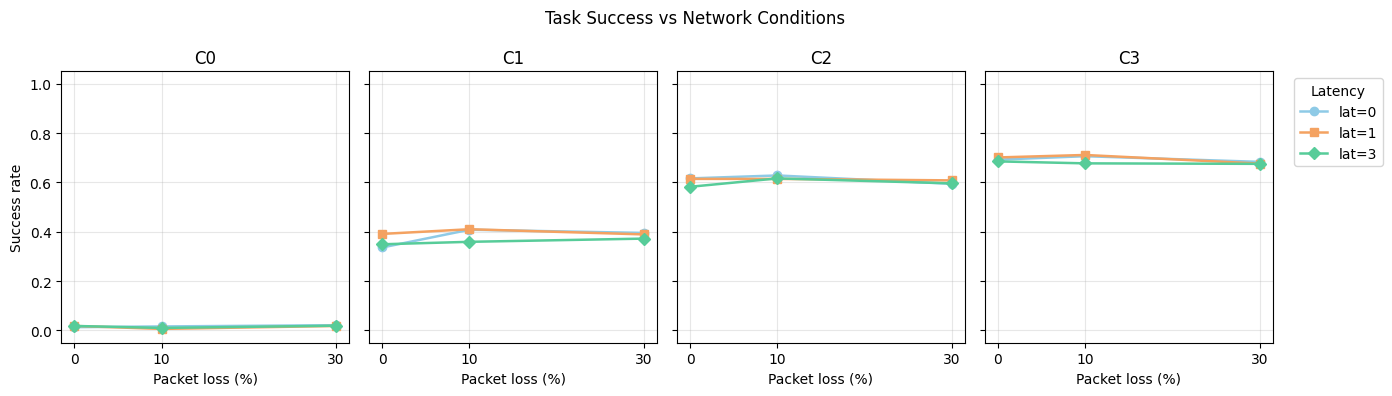

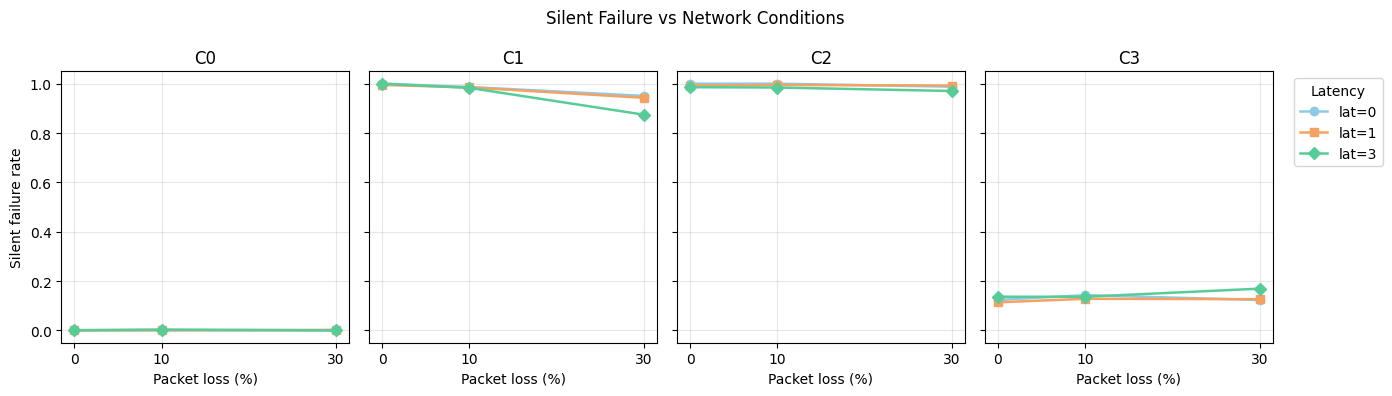

In [26]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def plot_robustness(df, metric, ylabel, title, filename):
    comms = ["C0", "C1", "C2", "C3"]
    latencies = sorted(df["latency"].unique())
    losses = sorted(df["loss"].unique())
    
    colors = {0: "#8ecae6", 1: "#f4a261", 3: "#57cc99"}
    markers = {0: "o", 1: "s", 3: "D"}

    fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
    fig.suptitle(title, fontsize=12)

    for ax, comm in zip(axes, comms):
        sub = df[df["comm"] == comm]
        for lat in latencies:
            lat_sub = sub[sub["latency"] == lat].sort_values("loss")
            ax.plot(
                lat_sub["loss"] * 100,
                lat_sub[metric],
                marker=markers[lat],
                color=colors[lat],
                label=f"lat={lat}",
                linewidth=1.8,
                markersize=6,
            )
        ax.set_title(comm)
        ax.set_xlabel("Packet loss (%)")
        ax.set_xticks([0, 10, 30])
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        if ax == axes[0]:
            ax.set_ylabel(ylabel)

    axes[-1].legend(title="Latency", bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

# Use min_agents=4 for the most dramatic results
df4 = df[df["min_agents"] == 4]

plot_robustness(df4, "success",     "Success rate",      
                "Task Success vs Network Conditions",       
                "fig_success_robustness.png")

plot_robustness(df4, "silent_fail", "Silent failure rate", 
                "Silent Failure vs Network Conditions",     
                "fig_silentfail_robustness.png")

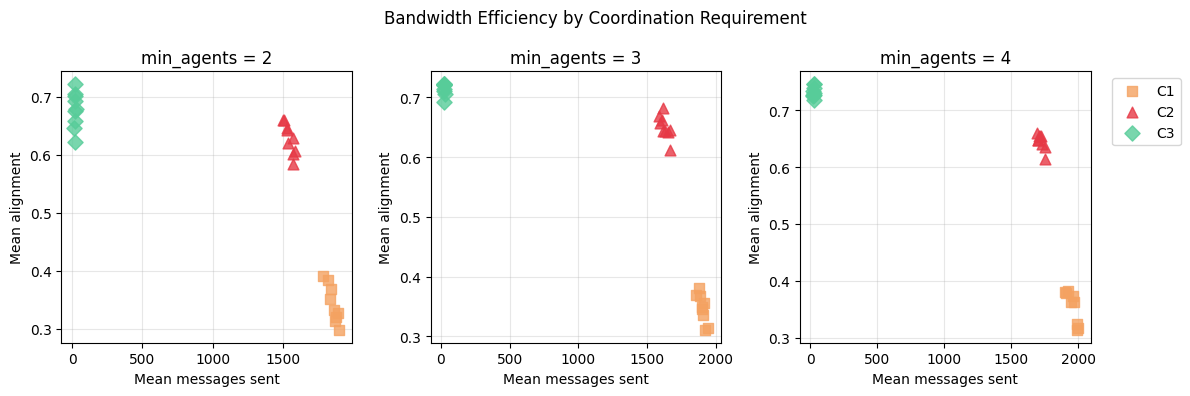

In [27]:
def plot_bandwidth(df, filename):
    comms = ["C1", "C2", "C3"]  # exclude C0 — no messages
    colors = {"C1": "#f4a261", "C2": "#e63946", "C3": "#57cc99"}
    markers = {"C1": "s", "C2": "^", "C3": "D"}

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
    fig.suptitle("Bandwidth Efficiency by Coordination Requirement", fontsize=12)

    for ax, n in zip(axes, [2, 3, 4]):
        sub = df[df["min_agents"] == n]
        for comm in comms:
            csub = sub[sub["comm"] == comm]
            ax.scatter(
                csub["msgs"],
                csub["alignment"],
                c=colors[comm],
                marker=markers[comm],
                label=comm,
                s=60, alpha=0.8, zorder=3,
            )
        ax.set_title(f"min_agents = {n}")
        ax.set_xlabel("Mean messages sent")
        ax.set_ylabel("Mean alignment")
        ax.grid(True, alpha=0.3)

    axes[-1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

plot_bandwidth(df, "fig_bandwidth.png")

In [28]:
for comm in ["C1", "C2", "C3"]:
    row = summary[(summary["comm"] == comm) & (summary["min_agents"] == 4)].iloc[0]
    p = row["success"]
    a = row["alignment"]
    print(f"{comm}: mean_alignment={a:.3f}, success={p:.3f}")
    print(f"  If alignment|success≈1: implied alignment|fail = {(a - p) / (1-p):.3f}")
    print(f"  If alignment|success≈0.7: implied alignment|fail = {(a - p*0.7) / (1-p):.3f}")

C1: mean_alignment=0.355, success=0.379
  If alignment|success≈1: implied alignment|fail = -0.039
  If alignment|success≈0.7: implied alignment|fail = 0.144
C2: mean_alignment=0.645, success=0.608
  If alignment|success≈1: implied alignment|fail = 0.094
  If alignment|success≈0.7: implied alignment|fail = 0.560
C3: mean_alignment=0.733, success=0.690
  If alignment|success≈1: implied alignment|fail = 0.139
  If alignment|success≈0.7: implied alignment|fail = 0.806


In [29]:
for comm in ["C1", "C2", "C3"]:
    row = summary[(summary["comm"]==comm) & (summary["min_agents"]==4)].iloc[0]
    p = row["success"]
    a = row["alignment"]
    a_fail = 0.05  # approximate
    if p > 0:
        a_success = (a - (1-p) * a_fail) / p
        print(f"{comm}: success-conditioned alignment ≈ {a_success:.3f}")

C1: success-conditioned alignment ≈ 0.855
C2: success-conditioned alignment ≈ 1.029
C3: success-conditioned alignment ≈ 1.040


In [30]:
# Back-calculate alignment|success using alignment|fail from silent failure structure
# For silent failures: agents agreed (low JSD) but wrong → alignment ≈ near zero
# For non-silent failures: agents disagreed → alignment varies

print("\n--- Estimating success-conditioned alignment ---")
for comm in ["C0", "C1", "C2", "C3"]:
    row = summary[(summary["comm"] == comm) & (summary["min_agents"] == 4)].iloc[0]
    p_success = row["success"]
    mean_align = row["alignment"]
    sf = row["silent_fail"]  # fraction of failures that are silent
    p_fail = 1 - p_success
    
    if p_success == 0:
        print(f"{comm}: no successes")
        continue
    
    # Silent failures have alignment ≈ 0 (agreed on wrong cell)
    # Non-silent failures have alignment ≈ uniform prior = 1/2500 ≈ 0
    # So alignment|fail ≈ small in both cases
    # Use 0.02 as a conservative estimate for alignment|fail
    a_fail_estimate = 0.02
    
    a_success = (mean_align - p_fail * a_fail_estimate) / p_success
    print(f"{comm}: alignment|success ≈ {a_success:.3f}  "
          f"(mean={mean_align:.3f}, p_success={p_success:.3f})")


--- Estimating success-conditioned alignment ---
C0: alignment|success ≈ 20.953  (mean=0.334, p_success=0.015)
C1: alignment|success ≈ 0.904  (mean=0.355, p_success=0.379)
C2: alignment|success ≈ 1.048  (mean=0.645, p_success=0.608)
C3: alignment|success ≈ 1.053  (mean=0.733, p_success=0.690)


In [31]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy import stats

# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------
with open("06APR_2.pkl", "rb") as f:
    results_2 = pickle.load(f)
with open("06APR_3.pkl", "rb") as f:
    results_3 = pickle.load(f)
with open("06APR_4.pkl", "rb") as f:
    results_4 = pickle.load(f)

# ---------------------------------------------------------------------------
# Style
# ---------------------------------------------------------------------------
COMM_COLORS = {
    "C0": "#8ecae6",
    "C1": "#f4a261",
    "C2": "#e63946",
    "C3": "#57cc99",
}
COMM_LABELS = {
    "C0": "C₀ None",
    "C1": "C₁ Semantic",
    "C2": "C₂ Epistemic",
    "C3": "C₃ Gated",
}
COMM_MARKERS = {"C0": "o", "C1": "s", "C2": "^", "C3": "D"}

def _comm_type(name):
    return name.split("_")[0]

def _loss_from_name(name):
    return float(name.split("_")[1].replace("loss", "")) / 100

def _latency_from_name(name):
    return int(name.split("_")[2].replace("lat", ""))

def legend_handles():
    return [
        Line2D([0],[0], color=COMM_COLORS[c], marker=COMM_MARKERS[c],
               label=COMM_LABELS[c], linewidth=1.8, markersize=6)
        for c in ["C0","C1","C2","C3"]
    ]

def stderr_band(ax, x, matrix, color, alpha_band=0.15):
    mean = np.nanmean(matrix, axis=0)
    se   = stats.sem(matrix, axis=0, nan_policy="omit")
    ax.plot(x, mean, color=color, linewidth=1.8)
    ax.fill_between(x, mean-se, mean+se, color=color, alpha=alpha_band)

# ---------------------------------------------------------------------------
# Build summary DataFrame from pkl files
# ---------------------------------------------------------------------------
def results_to_df(results, min_agents):
    rows = []
    for name, s in results.items():
        parts = name.split("_")
        comm = parts[0]
        loss = float(parts[1].replace("loss","")) / 100
        lat  = int(parts[2].replace("lat",""))
        sf   = s.silent_failure_rate_given_failure
        rows.append({
            "min_agents":    min_agents,
            "comm":          comm,
            "loss":          loss,
            "latency":       lat,
            "success":       s.task_success_rate,
            "time_to_success": s.mean_time_to_success,  # ADD THIS
            "silent_fail":   sf if not np.isnan(sf) else np.nan,
            "jsd":           s.mean_final_jsd,
            "alignment":     s.mean_final_alignment,
            "msgs":          s.mean_messages_sent,
            "apb":           s.mean_alignment_per_byte * 1e6
                             if s.mean_alignment_per_byte and
                             not np.isnan(s.mean_alignment_per_byte)
                             else np.nan,
        })
    return pd.DataFrame(rows)
    
df = pd.concat([
    results_to_df(results_2, 2),
    results_to_df(results_3, 3),
    results_to_df(results_4, 4),
], ignore_index=True)

summary = (
    df.groupby(["min_agents","comm"])
    .agg(
        success=("success","mean"),
        time_to_success=("time_to_success","mean"),  # ADD THIS
        silent_fail=("silent_fail","mean"),
        jsd=("jsd","mean"),
        alignment=("alignment","mean"),
        msgs=("msgs","mean"),
        apb=("apb","mean"),
    )
    .round(3)
    .reset_index()
)

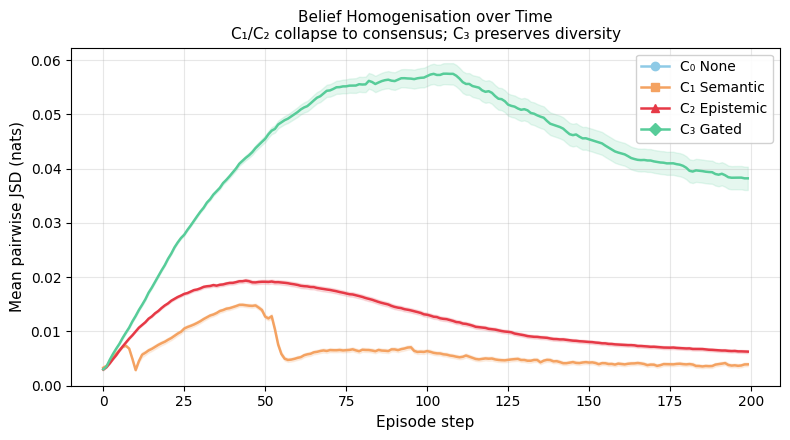

In [37]:
# ---------------------------------------------------------------------------
# Figure 1 — JSD time series
# Shows belief homogenisation: C1/C2 collapse to 0, C3 maintains diversity
# Use zero loss, zero latency from the 4-agent file (most dramatic)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))

for name, s in results_4.items():
    if _loss_from_name(name) != 0.0 or _latency_from_name(name) != 0:
        continue
    if s.jsd_matrix.shape[0] == 0:
        continue
    ct = _comm_type(name)
    if ct == "C0":
        continue
    T  = s.jsd_matrix.shape[1]
    stderr_band(ax, np.arange(T), s.jsd_matrix, COMM_COLORS[ct])

ax.set_xlabel("Episode step", fontsize=11)
ax.set_ylabel("Mean pairwise JSD (nats)", fontsize=11)
ax.set_title("Belief Homogenisation over Time\n"
             "C₁/C₂ collapse to consensus; C₃ preserves diversity",
             fontsize=11)
ax.set_ylim(bottom=0)
ax.legend(handles=legend_handles(), framealpha=0.9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig("fig1_jsd_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
print(s.jsd_matrix)

[[ 2.50434299e-03  3.34315110e-03  4.18398451e-03 ...  1.75129200e-01
   1.75509445e-01  1.75891871e-01]
 [ 2.50434299e-03  3.34315110e-03  4.25414878e-03 ... -9.99977878e-13
  -9.99977878e-13 -9.99977878e-13]
 [ 2.50434299e-03  3.34315110e-03  4.18398451e-03 ... -9.99977878e-13
  -9.99977878e-13 -9.99977878e-13]
 ...
 [ 2.50434299e-03  3.34315110e-03  4.18398451e-03 ...  1.58651203e-01
   1.58921686e-01  1.58672618e-01]
 [ 2.50434299e-03  3.34315110e-03  4.25414878e-03 ... -9.99977878e-13
  -9.99977878e-13 -9.99977878e-13]
 [ 2.50434299e-03  3.34315110e-03  4.18398451e-03 ... -9.99977878e-13
  -9.99977878e-13 -9.99977878e-13]]


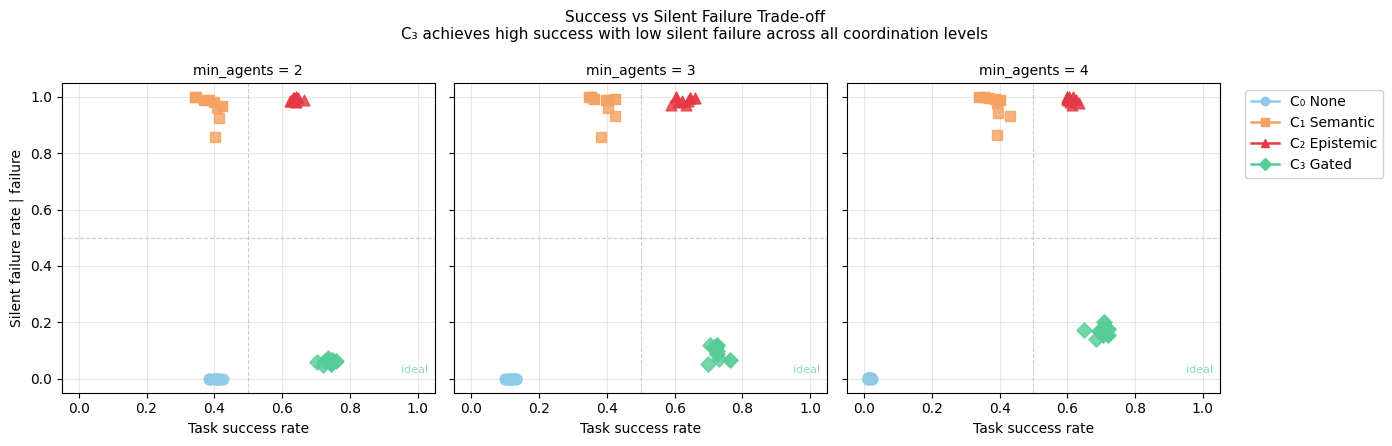

In [33]:
# ---------------------------------------------------------------------------
# Figure 2 — Success vs Silent Failure scatter
# Core tradeoff: x=success rate, y=silent failure rate
# One point per condition, all three min_agents levels
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True, sharex=True)

for ax, n, results in zip(axes, [2,3,4], [results_2, results_3, results_4]):
    for name, s in results.items():
        ct   = _comm_type(name)
        sf   = s.silent_failure_rate_given_failure
        succ = s.task_success_rate
        if np.isnan(sf):
            sf = 0.0
        loss = _loss_from_name(name)
        alpha = max(0.3, 1.0 - loss * 0.6)
        ax.scatter(succ, sf,
                   color=COMM_COLORS[ct],
                   marker=COMM_MARKERS[ct],
                   s=60, alpha=alpha, zorder=3)

    ax.set_title(f"min_agents = {n}", fontsize=10)
    ax.set_xlabel("Task success rate", fontsize=10)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.4)
    ax.axvline(0.5, color="gray", lw=0.8, ls="--", alpha=0.4)
    # Annotate ideal corner
    ax.annotate("ideal", xy=(0.95, 0.02), fontsize=8,
                color=COMM_COLORS["C3"], alpha=0.7)

axes[0].set_ylabel("Silent failure rate | failure", fontsize=10)
axes[-1].legend(handles=legend_handles(),
                bbox_to_anchor=(1.05,1), loc="upper left", framealpha=0.9)

fig.suptitle("Success vs Silent Failure Trade-off\n"
             "C₃ achieves high success with low silent failure across all coordination levels",
             fontsize=11)
fig.tight_layout()
plt.savefig("fig2_success_vs_silentfail.png", dpi=150, bbox_inches="tight")
plt.show()

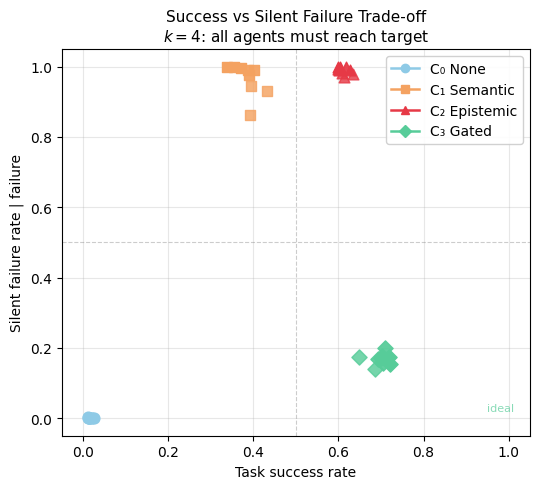

In [34]:
fig, ax = plt.subplots(figsize=(5.5, 5))

results = results_4  # k=4 only

for name, s in results.items():
    ct   = _comm_type(name)
    sf   = s.silent_failure_rate_given_failure
    succ = s.task_success_rate
    if np.isnan(sf):
        sf = 0.0
    loss = _loss_from_name(name)
    alpha = max(0.3, 1.0 - loss * 0.6)
    ax.scatter(succ, sf,
               color=COMM_COLORS[ct],
               marker=COMM_MARKERS[ct],
               s=60, alpha=alpha, zorder=3)

ax.set_xlabel("Task success rate", fontsize=10)
ax.set_ylabel("Silent failure rate | failure", fontsize=10)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.4)
ax.axvline(0.5, color="gray", lw=0.8, ls="--", alpha=0.4)
ax.annotate("ideal", xy=(0.95, 0.02), fontsize=8,
            color=COMM_COLORS["C3"], alpha=0.7)
ax.legend(handles=legend_handles(), framealpha=0.9)

ax.set_title("Success vs Silent Failure Trade-off\n"
             r"$k=4$: all agents must reach target",
             fontsize=11)

fig.tight_layout()
plt.savefig("fig2_success_vs_silentfail_k4.png", dpi=150, bbox_inches="tight")
plt.show()

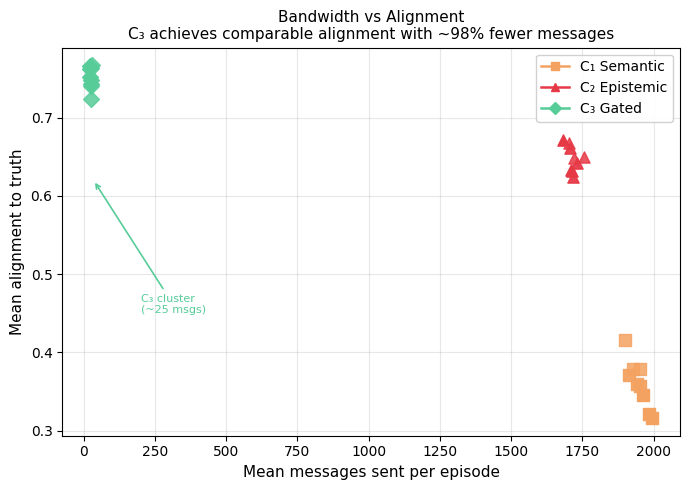

In [35]:
# ---------------------------------------------------------------------------
# Figure 3 — Messages sent vs alignment (bandwidth efficiency)
# C3 cluster bottom-left (few messages), C1/C2 cluster right
# Use 4-agent results, all conditions
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

for name, s in results_4.items():
    ct = _comm_type(name)
    if ct == "C0":
        continue   # no messages, not relevant here
    loss  = _loss_from_name(name)
    alpha = max(0.3, 1.0 - loss * 0.5)
    ax.scatter(s.mean_messages_sent, s.mean_final_alignment,
               color=COMM_COLORS[ct],
               marker=COMM_MARKERS[ct],
               s=65, alpha=alpha, zorder=3)

ax.set_xlabel("Mean messages sent per episode", fontsize=11)
ax.set_ylabel("Mean alignment to truth", fontsize=11)
ax.set_title("Bandwidth vs Alignment\n"
             "C₃ achieves comparable alignment with ~98% fewer messages",
             fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate the C3 cluster
ax.annotate("C₃ cluster\n(~25 msgs)",
            xy=(35, 0.62), xytext=(200, 0.45),
            fontsize=8, color=COMM_COLORS["C3"],
            arrowprops=dict(arrowstyle="->", color=COMM_COLORS["C3"], lw=1.2))

handles = [h for h in legend_handles() if h.get_label() != "C₀ None"]
ax.legend(handles=handles, framealpha=0.9)
fig.tight_layout()
plt.savefig("fig3_bandwidth_vs_alignment.png", dpi=150, bbox_inches="tight")
plt.show()

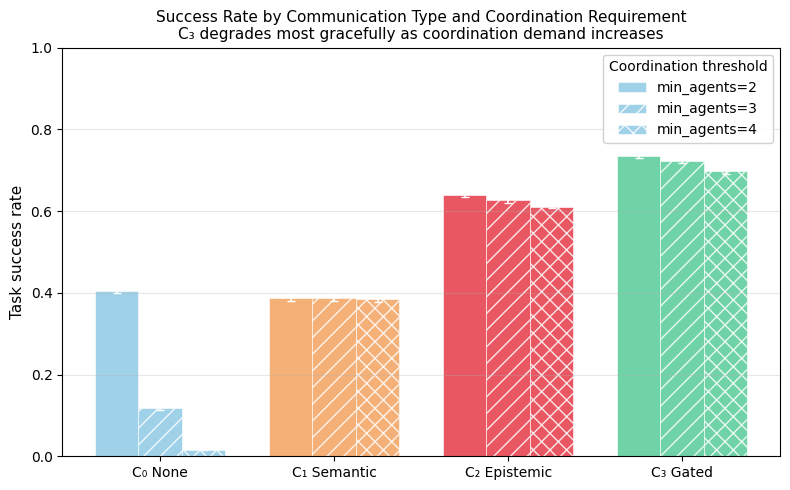

In [14]:
# ---------------------------------------------------------------------------
# Figure 4 — Success rate by coordination threshold
# Grouped bars: C0/C1/C2/C3 × min_agents=2/3/4
# Shows monotonic degradation and C3 robustness
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

comms      = ["C0","C1","C2","C3"]
n_comms    = len(comms)
min_agents = [2, 3, 4]
x          = np.arange(n_comms)
bar_width  = 0.25
offsets    = [-bar_width, 0, bar_width]
hatches    = ["", "//", "xx"]

for offset, n, hatch in zip(offsets, min_agents, hatches):
    vals = [
        summary[(summary["comm"]==c) & (summary["min_agents"]==n)]["success"].values[0]
        for c in comms
    ]
    se_vals = []
    for c in comms:
        results = {2: results_2, 3: results_3, 4: results_4}[n]
        successes = [s.task_success_rate for k,s in results.items()
                     if _comm_type(k) == c]
        se_vals.append(np.std(successes) / np.sqrt(len(successes)))

    bars = ax.bar(x + offset, vals, bar_width,
                  color=[COMM_COLORS[c] for c in comms],
                  alpha=0.85, hatch=hatch,
                  label=f"min_agents={n}",
                  edgecolor="white", linewidth=0.5)
    ax.errorbar(x + offset, vals, yerr=se_vals,
                fmt="none", color="white", capsize=3, lw=1.2)

ax.set_xticks(x)
ax.set_xticklabels([COMM_LABELS[c] for c in comms], fontsize=10)
ax.set_ylabel("Task success rate", fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_title("Success Rate by Communication Type and Coordination Requirement\n"
             "C₃ degrades most gracefully as coordination demand increases",
             fontsize=11)
ax.legend(title="Coordination threshold", framealpha=0.9)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.savefig("fig4_success_by_coordination.png", dpi=150, bbox_inches="tight")
plt.show()

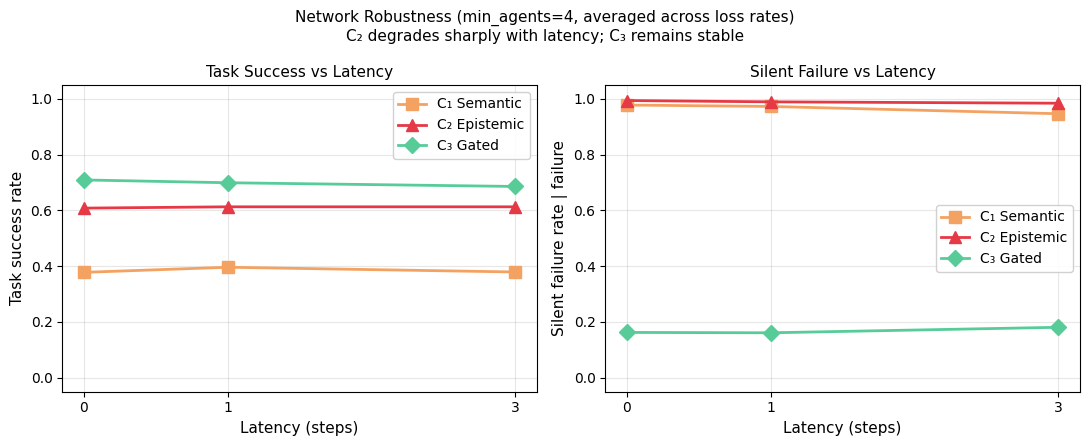

In [15]:
# ---------------------------------------------------------------------------
# Figure 5 — Robustness: C2 latency pathology
# Shows C2 degrading sharply at latency=3 vs C3 staying stable
# Use 4-agent results, zero packet loss, all latencies
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

latencies = [0, 1, 3]
line_styles = {0: "-", 1: "--", 3: ":"}

for ax, metric, ylabel, title in zip(
    axes,
    ["success", "silent_fail"],
    ["Task success rate", "Silent failure rate | failure"],
    ["Task Success vs Latency", "Silent Failure vs Latency"]
):
    for comm in ["C1","C2","C3"]:
        vals = []
        for lat in latencies:
            # Average across loss rates for this comm/latency
            matching = [
                s for name, s in results_4.items()
                if _comm_type(name) == comm and _latency_from_name(name) == lat
            ]
            if metric == "success":
                v = np.mean([s.task_success_rate for s in matching])
            else:
                sfs = [s.silent_failure_rate_given_failure for s in matching
                       if not np.isnan(s.silent_failure_rate_given_failure)]
                v = np.mean(sfs) if sfs else np.nan
            vals.append(v)

        ax.plot(latencies, vals,
                color=COMM_COLORS[comm],
                marker=COMM_MARKERS[comm],
                linewidth=2, markersize=8,
                label=COMM_LABELS[comm])

    ax.set_xlabel("Latency (steps)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(latencies)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(framealpha=0.9)

fig.suptitle("Network Robustness (min_agents=4, averaged across loss rates)\n"
             "C₂ degrades sharply with latency; C₃ remains stable",
             fontsize=11)
fig.tight_layout()
plt.savefig("fig5_latency_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
summary = (
    df.groupby(["min_agents","comm"])
    .agg(
        success=("success","mean"),
        time_to_success=("time_to_success","mean"),  # ADD THIS
        silent_fail=("silent_fail","mean"),
        jsd=("jsd","mean"),
        alignment=("alignment","mean"),
        msgs=("msgs","mean"),
        apb=("apb","mean"),
    )
    .round(3)
    .reset_index()
)

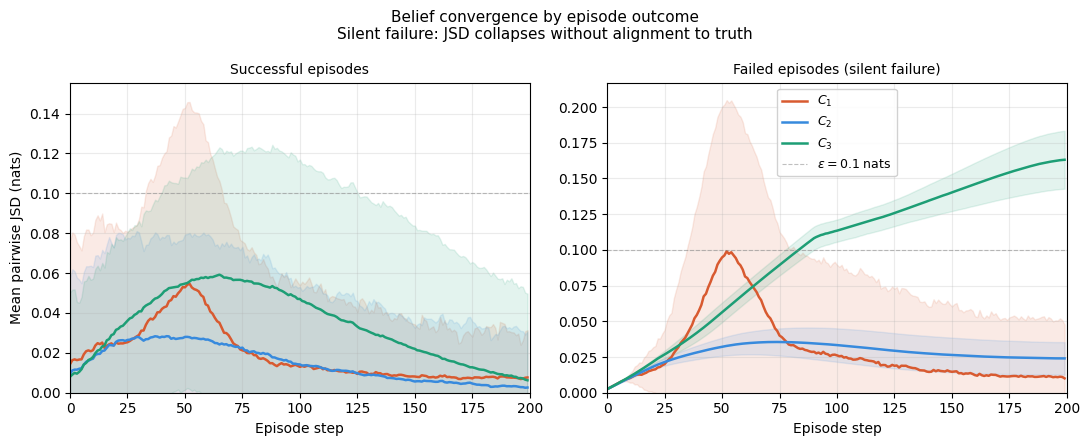

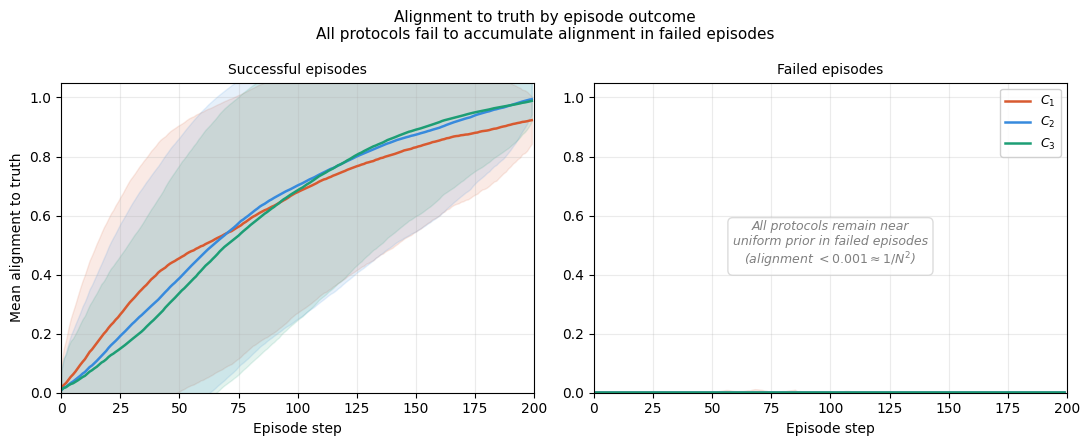

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

COMM_COLORS = {
    'C0': '#888780',
    'C1': '#D85A30', 
    'C2': '#378ADD',
    'C3': '#1D9E75',
}

ALIGNMENT_SUCCESS_THRESHOLD = 10/2500  # results hold from [0.001, 0.5] goiven bimodal distribution. 

def split_by_outcome(summary, align_thresh=ALIGNMENT_SUCCESS_THRESHOLD):
    """
    Split jsd_matrix and alignment_matrix rows into successful vs failed
    episodes based on final alignment value.
    """
    final_align = summary.alignment_matrix[:, -1]
    success_mask = final_align > align_thresh
    
    jsd_success   = summary.jsd_matrix[success_mask, :]
    jsd_failed    = summary.jsd_matrix[~success_mask, :]
    align_success = summary.alignment_matrix[success_mask, :]
    align_failed  = summary.alignment_matrix[~success_mask, :]
    
    return {
        'jsd_success':   jsd_success,
        'jsd_failed':    jsd_failed,
        'align_success': align_success,
        'align_failed':  align_failed,
        'n_success':     success_mask.sum(),
        'n_failed':      (~success_mask).sum(),
    }


def plot_jsd_by_outcome(results, target_condition='C2_loss00_lat0', 
                         comm_types=('C1', 'C2', 'C3')):
    """
    Two-panel figure: JSD over time split by episode outcome.
    Left panel: successful episodes. Right panel: failed episodes.
    Aggregates across all network conditions for each comm type.
    """
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)
    titles = ['Successful episodes', 'Failed episodes (silent failure)']
    keys   = ['jsd_success', 'jsd_failed']
    
    for ax, title, key in zip(axes, titles, keys):
        for ct in comm_types:
            # Aggregate across all network conditions for this comm type
            all_trajs = []
            for cname, summary in results.items():
                if not cname.startswith(ct):
                    continue
                split = split_by_outcome(summary)
                trajs = split[key]
                if trajs.shape[0] > 0:
                    all_trajs.append(trajs)
            
            if not all_trajs:
                continue
            
            combined = np.vstack(all_trajs)  # (total_eps, T)
            mean_jsd = combined.mean(axis=0)
            std_jsd  = combined.std(axis=0)
            steps    = np.arange(combined.shape[1])
            
            
            ax.plot(steps, mean_jsd, 
                    color=COMM_COLORS[ct], 
                    label=f'$C_{ct[1]}$',
                    linewidth=1.8)
            ax.fill_between(steps, 
                            mean_jsd - std_jsd, 
                            mean_jsd + std_jsd,
                            color=COMM_COLORS[ct], alpha=0.12)
        
        # Epsilon threshold line
        ax.axhline(0.1, color='gray', lw=0.8, ls='--', alpha=0.5,
                   label=r'$\epsilon = 0.1$ nats')
        
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Episode step', fontsize=10)
        ax.set_xlim(0, 200)
        ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.25)
    
    axes[0].set_ylabel('Mean pairwise JSD (nats)', fontsize=10)
    axes[1].legend(framealpha=0.9, fontsize=9)
    
    fig.suptitle(
        'Belief convergence by episode outcome\n'
        'Silent failure: JSD collapses without alignment to truth',
        fontsize=11
    )
    fig.tight_layout()
    plt.savefig('fig_jsd_by_outcome.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_alignment_by_outcome(results, comm_types=('C1', 'C2', 'C3')):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)
    titles = ['Successful episodes', 'Failed episodes']
    keys   = ['align_success', 'align_failed']
    
    for ax, title, key in zip(axes, titles, keys):
        for ct in comm_types:
            all_trajs = []
            for cname, summary in results.items():
                if not cname.startswith(ct):
                    continue
                split = split_by_outcome(summary)
                trajs = split[key]
                if trajs.shape[0] > 0:
                    all_trajs.append(trajs)
            
            if not all_trajs:
                continue
            
            combined  = np.vstack(all_trajs)
            mean_aln  = combined.mean(axis=0)
            std_aln   = combined.std(axis=0)
            steps     = np.arange(combined.shape[1])
            
            ax.plot(steps, mean_aln,
                    color=COMM_COLORS[ct],
                    label=f'$C_{ct[1]}$',
                    linewidth=1.8)
            ax.fill_between(steps,
                            mean_aln - std_aln,
                            mean_aln + std_aln,
                            color=COMM_COLORS[ct], alpha=0.12)
        
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Episode step', fontsize=10)
        ax.set_xlim(0, 200)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.25)
    
    # Annotation on failed panel only
    axes[1].text(
        100, 0.5,
        'All protocols remain near\nuniform prior in failed episodes\n'
        r'(alignment $< 0.001 \approx 1/N^2$)',
        ha='center', va='center', fontsize=9,
        color='gray', style='italic',
        bbox=dict(boxstyle='round,pad=0.4', 
                  facecolor='white', 
                  edgecolor='lightgray', 
                  alpha=0.8)
    )
    
    axes[0].set_ylabel('Mean alignment to truth', fontsize=10)
    axes[1].legend(framealpha=0.9, fontsize=9)
    
    fig.suptitle(
        'Alignment to truth by episode outcome\n'
        'All protocols fail to accumulate alignment in failed episodes',
        fontsize=11
    )
    fig.tight_layout()
    plt.savefig('fig_alignment_by_outcome.png', dpi=150, bbox_inches='tight')
    plt.show()


# --- Run ---
with open('09APR_4.pkl', 'rb') as f:
    results = pickle.load(f)

plot_jsd_by_outcome(results)
plot_alignment_by_outcome(results)